In [68]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 假设你有一个包含历史波高数据的数组
# 这里仅作示例，实际应用中需要根据你的数据来加载和处理

eta00 = np.load('Main_Project_file/data/data/ceshi.npy')


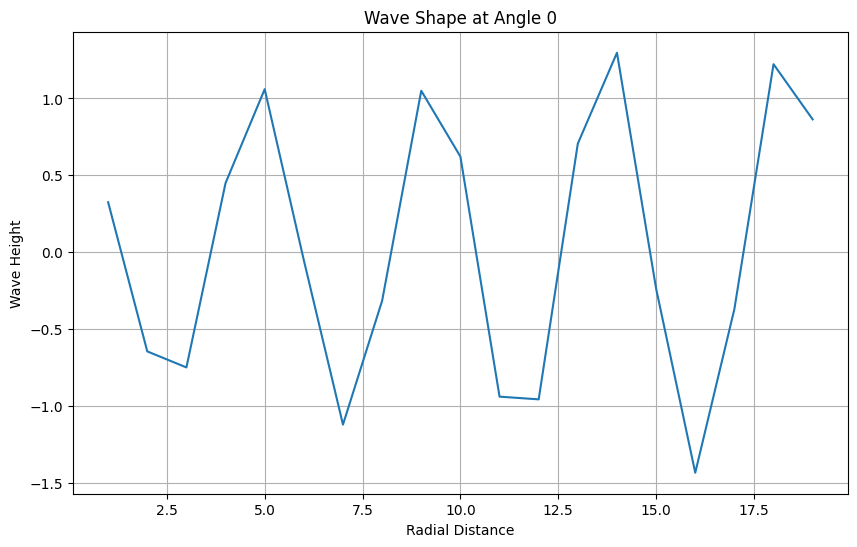

In [69]:
import matplotlib.pyplot as plt
y = eta00[:19,100,300]
x = np.linspace(1, 19, 19)
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()



In [38]:
# 利用RNN构建前10步预测后面的十步的数据集
data = eta00[:,20,60:70]



(4000, 10)

In [39]:
class Net(nn.Module):
    def __init__(self, ):
        super(Net, self).__init__() #调用了父类 nn.Module 的构造函数

        self.rnn = nn.GRU(
            input_size=10,
            hidden_size=64,
            num_layers=2,
            batch_first=False,
        )
        # for p in self.rnn.parameters():
        #     nn.init.normal_(p, mean=0.0, std=0.001)   # 对参数进行初值化

        self.linear = nn.Linear(64, 10)

    def forward(self, x):
        out, _ = self.rnn(x)  # [b, seq, h]
        out = self.linear(out)
        return out

In [40]:
model = Net().to('cuda')
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), 0.01)

In [41]:
for epoch in range(3000):
    
    model.train()
    train_loss = 0
    
    for i in range(2000):
        X = data[0+i:30+i]
        
        Y = data[30+i:60+i]
        
        
        X_tensor = torch.Tensor(X).to('cuda')
        
        Y_tensor = torch.Tensor(Y).to('cuda')

        output = model(X_tensor)

        loss = loss_fn(output, Y_tensor)
        train_loss += loss.item() 

        
        optimizer.zero_grad()

        
        loss.backward()


        optimizer.step()

    train_loss = train_loss = train_loss / 100

    print('train_loss=',train_loss )
    

   

    if epoch % 10 == 0:
        model.eval() 
        test_loss = 0
        for i in range(20):
            X = data[2500+i:2530+i]
            Y = data[2530+i:2560+i]

            X_tensor = torch.Tensor(X).to('cuda')
            Y_tensor = torch.Tensor(Y).to('cuda')
            output = model(X_tensor)
            
            loss = loss_fn(output, Y_tensor)

            test_loss += loss.item()

        print('test_loss=',test_loss/20)

    
# torch.save(model.state_dict(), 'model_parameters.pth')

train_loss= 0.4314978352421895
test_loss= 0.025244530849158765
train_loss= 0.574943533684127
train_loss= 0.5257544203009457
train_loss= 0.3478313170792535
train_loss= 0.23163303673733027
train_loss= 0.19283663351088762
train_loss= 0.16036354805342853
train_loss= 0.1438733233953826
train_loss= 0.11819581961492076
train_loss= 0.11681185664609074
train_loss= 0.11280956766800955
test_loss= 0.013384756888262928
train_loss= 0.10138521896908059
train_loss= 0.11128398862667382
train_loss= 0.09602075464907102
train_loss= 0.0883852332807146
train_loss= 0.08029031762853264
train_loss= 0.0811639781773556
train_loss= 0.07168198394589126
train_loss= 0.07854832232929766
train_loss= 0.07338772418443114
train_loss= 0.06221312566078268
test_loss= 0.004243474884424359
train_loss= 0.06046031174017116
train_loss= 0.07572755350614897
train_loss= 0.06572905072127469
train_loss= 0.05767711293650791
train_loss= 0.05976259530871175
train_loss= 0.06606179144233465
train_loss= 0.06402511407621204
train_loss= 0.06

KeyboardInterrupt: 

In [60]:
X = data[3000:3030]
X_tensor = torch.Tensor(X).to('cuda')
pre = model(X_tensor)
pre_array = pre.cpu().detach().numpy()
c = pre_array[29,:]
print(c.shape)
Y = data[3030:3060]
print(Y.shape)


y = Y[29,:]

(10,)
(30, 10)


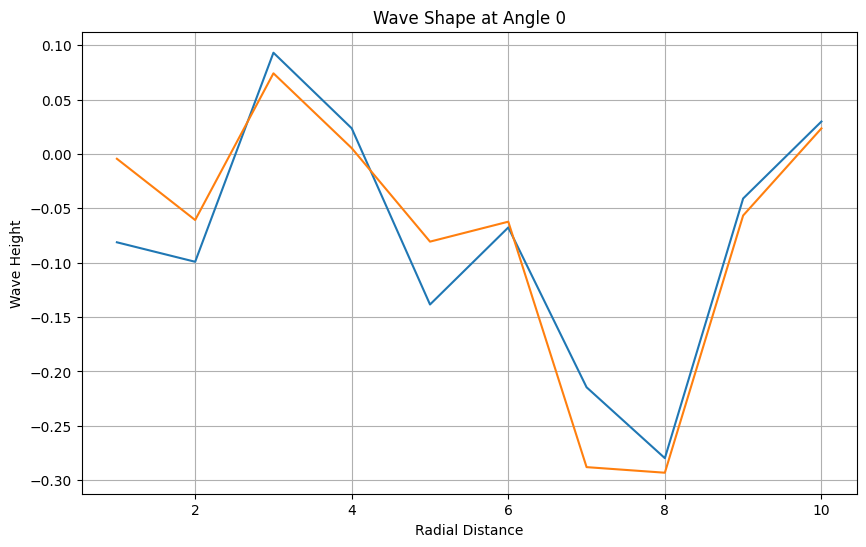

In [61]:
import matplotlib.pyplot as plt
# y = eta00[:100,0,100]
x = np.linspace(1, 10, 10)
plt.figure(figsize=(10, 6))
plt.plot(x, y) #zheng
plt.plot(x, c) #yuce
plt.title('Wave Shape at Angle 0')
plt.xlabel('Radial Distance')
plt.ylabel('Wave Height')
plt.grid(True)
plt.show()